In [9]:
import sys
sys.path.append('bev')

from plan import Plan

In [10]:
plan = Plan(
    img_file_path=r"data/DoseRAD2026/photon/training/1ABB006/image/ct.mha",
    info_json_path=r"data/DoseRAD2026/photon/training/1ABB006/1ABB006.json",
    dose_dir=r"data/DoseRAD2026/photon/training/1ABB006/dose",
)

In [5]:
print(plan.beam_info)

OrderedDict([(0, {'sad': 1000, 'isocentre': [-46.8471844842125, 27.777663262437926, -28.13538836315937], 'n_mlc_leaf': 80, 'n_cp': 180}), (1, {'sad': 1000, 'isocentre': [-46.8471844842125, 27.777663262437926, -8.135388363159374], 'n_mlc_leaf': 80, 'n_cp': 180}), (2, {'sad': 1000, 'isocentre': [-46.8471844842125, 27.777663262437926, 11.864611636840626], 'n_mlc_leaf': 80, 'n_cp': 180})])


In [6]:
beam_id, cp_idx = 0, 23
plan.set_state(beam_id=beam_id, cp_idx=cp_idx)

In [78]:
a = sitk.GetArrayFromImage(plan.img_rot)
b = sitk.GetArrayFromImage(plan.dose_rot)
c = sitk.GetArrayFromImage(plan.mask_rot)
d = sitk.GetArrayFromImage(plan.bev)

In [13]:
plan.img.TransformPhysicalPointToIndex(plan.isocentre) 

(102, 139, 109)

Text(0.5, 1.0, 'CP 23')

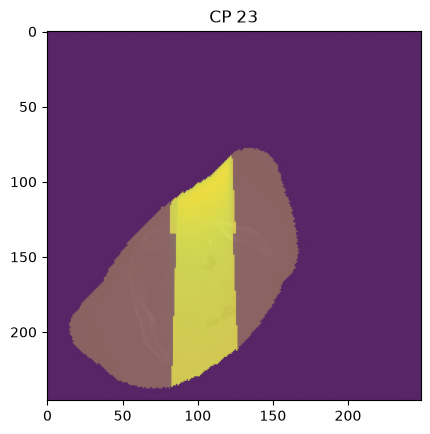

In [15]:
plt.imshow(a[102, :, :], alpha=0.4, cmap="gray")
plt.imshow(b[102, :, :], alpha=0.4)
plt.imshow(c[102, :, :], alpha=0.4)
plt.imshow(d[102, :, :], alpha=0.4)
plt.title(f"CP {cp_idx}")

In [16]:
import numpy as np
import torch
import torch.nn.functional as F


def rotate_image_torch(
    image_np,
    spacing,
    origin,
    isocentre,
    degree,
    axis="z",
    bg_value=-1024,
    pad_voxels=None,
):
    """PyTorch GPU implementation of rotate_image_sitk.

    Args:
        image_np: NumPy array of shape (D, H, W) -> equivalent to SITK (Z, Y,
          X)
        spacing: Tuple/list of (sp_x, sp_y, sp_z) from image.GetSpacing()
        origin: Tuple/list of (ori_x, ori_y, ori_z) from image.GetOrigin()
        isocentre: Tuple/list of physical coordinates (iso_x, iso_y, iso_z)
        degree: Rotation angle in degrees
        axis: Rotation axis ("x", "y", or "z")
        bg_value: Padding/Background value (default: -1024 for CT HU)
        pad_voxels: Tuple of (pad_x, pad_y, pad_z) to match your padding function

    Returns:
        rotated_np: NumPy array of the rotated volume (D, H, W)
    """
    # 1. Flip degree to match your operational logic
    angle = -degree
    rad = np.deg2rad(angle)
    cos_a, sin_a = np.cos(rad), np.sin(rad)

    # SimpleITK size matches (W, H, D) -> array shape is (D, H, W)
    D, H, W = image_np.shape
    size_xyz = np.array([W, H, D], dtype=np.float32)
    spacing_xyz = np.array(spacing, dtype=np.float32)
    origin_xyz = np.array(origin, dtype=np.float32)
    iso_xyz = np.array(isocentre, dtype=np.float32)

    # 2. Convert the physical isocenter to continuous voxel indices (X, Y, Z)
    iso_voxel = (iso_xyz - origin_xyz) / spacing_xyz

    # 3. Handle grid dimensions if padding is requested
    if pad_voxels is not None:
        # Replicating your padding adjustments to size and origin shifts
        pad_xyz = np.array(pad_voxels, dtype=np.float32)
        new_size_xyz = size_xyz + 2 * pad_xyz
        # Track the new shifted origin in voxel space
        iso_voxel = iso_voxel + pad_xyz
        out_size_th = (
            1,
            1,
            int(new_size_xyz[2]),
            int(new_size_xyz[1]),
            int(new_size_xyz[0]),
        )
    else:
        new_size_xyz = size_xyz
        out_size_th = (1, 1, D, H, W)

    # 4. Normalize the continuous voxel isocenter to PyTorch [-1, 1] coordinate space
    # PyTorch coordinates use (X, Y, Z) arrangement for affine_grid computation mapping
    iso_pt = (2.0 * iso_voxel / (new_size_xyz - 1.0)) - 1.0
    x_c, y_c, z_c = iso_pt[0], iso_pt[1], iso_pt[2]

    # 5. Build the explicit 3x4 affine matrix rotating around the sub-voxel isocenter
    if axis == "z":  # Rotation around Z axis (affects X and Y)
        matrix = np.array(
            [
                [cos_a, -sin_a, 0, x_c * (1 - cos_a) + y_c * sin_a],
                [sin_a, cos_a, 0, -x_c * sin_a + y_c * (1 - cos_a)],
                [0, 0, 1, z_c * (1 - 1)],
            ],
            dtype=np.float32,
        )
    elif axis == "y":  # Rotation around Y axis (affects X and Z)
        matrix = np.array(
            [
                [cos_a, 0, sin_a, x_c * (1 - cos_a) - z_c * sin_a],
                [0, 1, 0, y_c * (1 - 1)],
                [-sin_a, 0, cos_a, x_c * sin_a + z_c * (1 - cos_a)],
            ],
            dtype=np.float32,
        )
    elif axis == "x":  # Rotation around X axis (affects Y and Z)
        matrix = np.array(
            [
                [1, 0, 0, x_c * (1 - 1)],
                [0, cos_a, -sin_a, y_c * (1 - cos_a) + z_c * sin_a],
                [0, sin_a, cos_a, -y_c * sin_a + z_c * (1 - cos_a)],
            ],
            dtype=np.float32,
        )

    # 6. Ship data structures to the GPU
    # Pad input image if padding was specified
    if pad_voxels is not None:
        p_z, p_y, p_x = int(pad_voxels[2]), int(pad_voxels[1]), int(pad_voxels[0])
        # F.pad expects inputs from last dimension backward: (left, right, top, bottom, front, back)
        image_np = np.pad(
            image_np,
            ((p_z, p_z), ((p_y, p_y)), ((p_x, p_x))),
            mode='constant',
            constant_values=bg_value,
        )

    tensor_img = (
        torch.from_numpy(image_np)
        .float()
        .unsqueeze(0)
        .unsqueeze(0)
        .cuda()  # (B, C, D, H, W)
    )
    batch_matrix = torch.from_numpy(matrix).unsqueeze(0).cuda()  # (B, 3, 4)

    # 7. Generate sampling grid and process trilinear interpolation on GPU
    grid = F.affine_grid(
        batch_matrix, size=out_size_th, align_corners=True
    )  # Keep align_corners=True for sub-voxel tracking

    # Map background values away from default zero using grid_sample setup
    # We shift intensity, sample, and shift back to respect custom bg_value cleanly
    tensor_img = tensor_img - bg_value
    rotated_tensor = F.grid_sample(
        tensor_img,
        grid,
        mode="bilinear",
        padding_mode="zeros",
        align_corners=True,
    )
    rotated_tensor = rotated_tensor + bg_value

    # 8. Unpack matrix output to host memory format
    return rotated_tensor.squeeze().cpu().numpy()


In [17]:
plan.img.GetSpacing()

(2.0, 2.0, 2.0)

In [19]:
plan.img.GetOrigin()

(-250.0, -250.0, -246.0)

In [20]:
plan.isocentre

[-46.8471844842125, 27.777663262437926, -28.13538836315937]

In [85]:
%time
a_ = rotate_image_torch(
    a,
    plan.img.GetSpacing(),
    plan.img.GetOrigin(),
    plan.isocentre,
    25,
    axis="z",
    bg_value=-1024,
    pad_voxels=None,
)

CPU times: user 7 μs, sys: 7 μs, total: 14 μs
Wall time: 28.4 μs


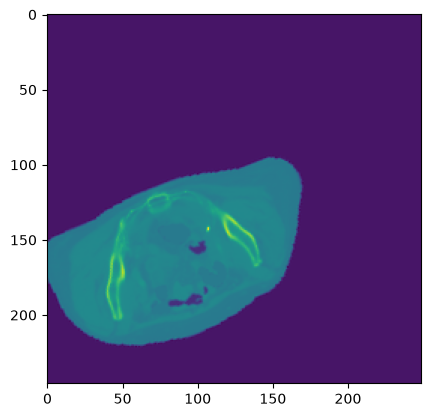

In [86]:
plt.imshow(a_[102])

In [31]:
a.shape, a_.shape

((246, 246, 249), (246, 246, 249))

In [73]:
import torch
import torch.nn.functional as F
import numpy as np

def rotate_image_torch_batched(
    tensor_img,     # Expected shape: (D, H, W) or (1, 1, D, H, W) on GPU
    spacing, 
    origin, 
    isocentre, 
    degrees_list,   # Iterable containing your 180 control point angles
    axis="z", 
    bg_value=-1024, 
    pad_voxels=None
):
    """
    Batched PyTorch GPU implementation accepting a PyTorch tensor input.
    Processes all 180 control points simultaneously.
    
    Returns:
        rotated_tensor: Tensor of shape (180, D, H, W) on the same GPU.
    """
    # 1. Standardise tensor dimensions to 5D format: (1, 1, D, H, W)
    if tensor_img.dim() == 3:
        tensor_img = tensor_img.unsqueeze(0).unsqueeze(0)
    elif tensor_img.dim() == 4:
        tensor_img = tensor_img.unsqueeze(0) # Assumes Channel dim exists
        
    _, _, D, H, W = tensor_img.shape
    device = tensor_img.device
    
    size_xyz = np.array([W, H, D], dtype=np.float32)
    spacing_xyz = np.array(spacing, dtype=np.float32)
    origin_xyz = np.array(origin, dtype=np.float32)
    iso_xyz = np.array(isocentre, dtype=np.float32)

    # 2. Convert physical isocentre to continuous voxel index
    iso_voxel = (iso_xyz - origin_xyz) / spacing_xyz

    # 3. Handle tensor padding shifts if requested
    if pad_voxels is not None:
        pad_xyz = np.array(pad_voxels, dtype=np.float32)
        new_size_xyz = size_xyz + 2 * pad_xyz
        iso_voxel = iso_voxel + pad_xyz
        
        p_z, p_y, p_x = int(pad_voxels[2]), int(pad_voxels[1]), int(pad_voxels[0])
        # F.pad format: (left, right, top, bottom, front, back) corresponding to (X, Y, Z)
        tensor_img = F.pad(tensor_img, (p_x, p_x, p_y, p_y, p_z, p_z), mode='constant', value=bg_value)
        _, _, out_D, out_H, out_W = tensor_img.shape
    else:
        new_size_xyz = size_xyz
        out_D, out_H, out_W = D, H, W

    # 4. Normalize isocentre to PyTorch coordinate space [-1, 1]
    iso_pt = (2.0 * iso_voxel / (new_size_xyz - 1.0)) - 1.0
    x_c, y_c, z_c = iso_pt[0], iso_pt[1], iso_pt[2]

    # 5. Build 3x4 affine matrices for all angles on host CPU
    matrices_list = []
    for degree in degrees_list:
        angle = -degree
        rad = np.deg2rad(angle)
        cos_a, sin_a = np.cos(rad), np.sin(rad)

        if axis == "z":
            matrix = [[cos_a, -sin_a, 0, x_c*(1-cos_a) + y_c*sin_a],
                      [sin_a,  cos_a, 0, -x_c*sin_a + y_c*(1-cos_a)],
                      [0,      0,     1, 0.0]]
        elif axis == "y":
            matrix = [[cos_a,  0, sin_a, x_c*(1-cos_a) - z_c*sin_a],
                      [0,      1, 0,     0.0],
                      [-sin_a, 0, cos_a, x_c*sin_a + z_c*(1-cos_a)]]
        elif axis == "x":
            matrix = [[1, 0,     0,      0.0],
                      [0, cos_a, -sin_a, y_c*(1-cos_a) + z_c*sin_a],
                      [0, sin_a,  cos_a, -y_c*sin_a + z_c*(1-cos_a)]]
        matrices_list.append(matrix)

    num_batch = len(degrees_list)
    print(type(matrices_list[0][0]))
    
    # 6. Upload matrices to the target GPU device
    batch_matrices = torch.tensor(matrices_list, dtype=torch.float32, device=device)
    
    # Expand tensor along the batch dimension to process parallel views
    # .expand() creates virtual views to avoid duplicating hardware memory blocks
    batched_img = tensor_img.expand(num_batch, -1, -1, -1, -1) - bg_value

    # 7. Compute transformations concurrently on GPU execution grid
    grid = F.affine_grid(batch_matrices, size=(num_batch, 1, out_D, out_H, out_W), align_corners=True)
    rotated_tensor = F.grid_sample(batched_img, grid, mode='bilinear', padding_mode='zeros', align_corners=True)
    
    # Restore actual background HU radiation values
    rotated_tensor = rotated_tensor + bg_value

    # Return clean shape: (180, D, H, W) remaining on GPU memory
    return rotated_tensor.squeeze(1), matrices_list


In [63]:
a = torch.tensor(a).cuda()

/tmp/ipykernel_32168/1618504210.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  a = torch.tensor(a).cuda()


In [64]:
torch.cuda.empty_cache()

In [74]:
# %time
a_, m = rotate_image_torch_batched(
    a,
    plan.img.GetSpacing(),
    plan.img.GetOrigin(),
    plan.isocentre,
    range(1),
    axis="z",
    bg_value=-1024,
    pad_voxels=None,
)

<class 'list'>


In [76]:
m[0][0]

[np.float64(1.0), np.float64(-0.0), 0, np.float64(0.0)]

In [57]:
a_.device

device(type='cuda', index=0)

# Pure Torch implementation

In [2]:
import torch
import torch.nn.functional as F

def rotate_image_batched(
    tensor_img,     # Shape: (D, H, W) or (1, 1, D, H, W) on GPU
    spacing,        # Can now be a torch.Tensor or list/tuple
    origin,         # Can now be a torch.Tensor or list/tuple
    isocentre,      # Can now be a torch.Tensor or list/tuple
    degrees_list,   # Can now be a torch.Tensor of shape (180,) on GPU
    axis="z", 
    bg_value=-1024, 
    pad_voxels=None
):
    """
    100% pure PyTorch GPU implementation. No NumPy operations.
    Processes all control points concurrently on the GPU.
    """
    # 1. Standardise tensor dimensions to 5D format: (1, 1, D, H, W)
    if tensor_img.dim() == 3:
        tensor_img = tensor_img.unsqueeze(0).unsqueeze(0)
    elif tensor_img.dim() == 4:
        tensor_img = tensor_img.unsqueeze(0)
        
    _, _, D, H, W = tensor_img.shape
    device = tensor_img.device
    
    # 2. Convert metadata inputs directly to PyTorch tensors on the same GPU
    size_xyz = torch.tensor([W, H, D], dtype=torch.float32, device=device)
    spacing_xyz = torch.as_tensor(spacing, dtype=torch.float32, device=device)
    origin_xyz = torch.as_tensor(origin, dtype=torch.float32, device=device)
    iso_xyz = torch.as_tensor(isocentre, dtype=torch.float32, device=device)
    angles_deg = torch.as_tensor(degrees_list, dtype=torch.float32, device=device)

    # 3. Calculate continuous voxel index on GPU
    iso_voxel = (iso_xyz - origin_xyz) / spacing_xyz

    # 4. Handle GPU padding shifts if requested
    if pad_voxels is not None:
        pad_xyz = torch.as_tensor(pad_voxels, dtype=torch.float32, device=device)
        new_size_xyz = size_xyz + 2 * pad_xyz
        iso_voxel = iso_voxel + pad_xyz
        
        p_z, p_y, p_x = int(pad_voxels[0]), int(pad_voxels[1]), int(pad_voxels[2])
        tensor_img = F.pad(tensor_img, (p_x, p_x, p_y, p_y, p_z, p_z), mode='constant', value=bg_value)
        _, _, out_D, out_H, out_W = tensor_img.shape
    else:
        new_size_xyz = size_xyz
        out_D, out_H, out_W = D, H, W

    # 5. Normalize isocentre to PyTorch coordinate space [-1, 1]
    iso_pt = (2.0 * iso_voxel / (new_size_xyz - 1.0)) - 1.0
    x_c, y_c, z_c = iso_pt[0], iso_pt[1], iso_pt[2]

    # 6. Compute trigonometry vectors in parallel for all 180 angles on GPU
    rad = torch.deg2rad(-angles_deg)  # Flip degree to match your operational logic
    cos_a = torch.cos(rad)
    sin_a = torch.sin(rad)
    
    num_batch = len(degrees_list)
    zeros = torch.zeros(num_batch, device=device)
    ones = torch.ones(num_batch, device=device)

    # 7. Construct the batched 3x4 affine matrices in parallel on GPU
    if axis == "z":
        row0 = torch.stack([cos_a, -sin_a, zeros, x_c * (1 - cos_a) + y_c * sin_a], dim=1)
        row1 = torch.stack([sin_a, cos_a, zeros, -x_c * sin_a + y_c * (1 - cos_a)], dim=1)
        row2 = torch.stack([zeros, zeros, ones, zeros], dim=1)
    elif axis == "y":
        row0 = torch.stack([cos_a, zeros, sin_a, x_c * (1 - cos_a) - z_c * sin_a], dim=1)
        row1 = torch.stack([zeros, ones, zeros, zeros], dim=1)
        row2 = torch.stack([-sin_a, zeros, cos_a, x_c * sin_a + z_c * (1 - cos_a)], dim=1)
    elif axis == "x":
        row0 = torch.stack([ones, zeros, zeros, zeros], dim=1)
        row1 = torch.stack([zeros, cos_a, -sin_a, y_c * (1 - cos_a) + z_c * sin_a], dim=1)
        row2 = torch.stack([zeros, sin_a, cos_a, -y_c * sin_a + z_c * (1 - cos_a)], dim=1)

    # Shape: (180, 3, 4)
    batch_matrices = torch.stack([row0, row1, row2], dim=1)
    
    # 8. Expand input image and apply the math-shift workaround
    batched_img = tensor_img.expand(num_batch, -1, -1, -1, -1) - bg_value

    # 9. Execute grid interpolation entirely inside VRAM cores
    grid = F.affine_grid(batch_matrices, size=(num_batch, 1, out_D, out_H, out_W), align_corners=True)
    rotated_tensor = F.grid_sample(batched_img, grid, mode='bilinear', padding_mode='zeros', align_corners=True)
    
    # Restore background HU radiation values
    rotated_tensor = rotated_tensor + bg_value

    return rotated_tensor.squeeze(1)


In [3]:
import SimpleITK as sitk

In [22]:
img = sitk.ReadImage('data/DoseRAD2026/photon/training/1ABB006/image/ct.mha')
img_arr = sitk.GetArrayFromImage(img)
img_tensor = torch.tensor(img_arr)

In [10]:
torch.cuda.empty_cache()

In [19]:
torch.cuda.memory_reserved()

11851005952

In [18]:
torch.cuda.memory_allocated()

11844408832

In [11]:
!nvidia-smi

Fri Aug  7 07:16:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 2000 Ada Gene...    On  |   00000000:81:00.0 Off |                  Off |
| 30%   34C    P2             18W /   70W |   13164MiB /  16380MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
isocentre = [-46.8471844842125, 27.777663262437926, -8.135388363159374]

In [25]:
img_rot = rotate_image_batched(
    img_tensor,
    img.GetSpacing(),
    img.GetOrigin(),
    isocentre,
    range(180),
    axis="z",
    bg_value=-1024,
    pad_voxels=None,
)

: 

In [ ]:
# %time
img_rot = []

for i in range(10):
    a = rotate_image_batched(
    img_tensor,
    img.GetSpacing(),
    img.GetOrigin(),
    isocentre,
    range((i*18), (i+1)*18),
    axis="z",
    bg_value=-1024,
    pad_voxels=None,
)
    b = a.numpy()
    img_rot.append(b)
    del rot
    torch.cuda.empty_cache()


NameError: name 'a' is not defined

In [ ]:
# %time
img_rot = [rotate_image_batched(
    img_tensor,
    img.GetSpacing(),
    img.GetOrigin(),
    isocentre,
    [i],
    axis="z",
    bg_value=-1024,
    pad_voxels=None,
) for i in range(180)]

In [123]:
18.4*180/1000

3.3119999999999994

In [14]:
img_rot.cpu().numpy()

array([[[[-1024., -1024., -1024., ..., -1024., -1024., -1024.],
         [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
         [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
         ...,
         [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
         [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
         [-1024., -1024., -1024., ..., -1024., -1024., -1024.]],

        [[-1024., -1024., -1024., ..., -1024., -1024., -1024.],
         [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
         [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
         ...,
         [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
         [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
         [-1024., -1024., -1024., ..., -1024., -1024., -1024.]],

        [[-1024., -1024., -1024., ..., -1024., -1024., -1024.],
         [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
         [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
        

In [128]:
np.stack([i.cpu().numpy() for i in img_rot])

array([[[[[-1024., -1024., -1024., ..., -1024., -1024., -1024.],
          [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
          [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
          ...,
          [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
          [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
          [-1024., -1024., -1024., ..., -1024., -1024., -1024.]],

         [[-1024., -1024., -1024., ..., -1024., -1024., -1024.],
          [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
          [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
          ...,
          [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
          [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
          [-1024., -1024., -1024., ..., -1024., -1024., -1024.]],

         [[-1024., -1024., -1024., ..., -1024., -1024., -1024.],
          [-1024., -1024., -1024., ..., -1024., -1024., -1024.],
          [-1024., -1024., -1024., ..., -1024., -1024., 

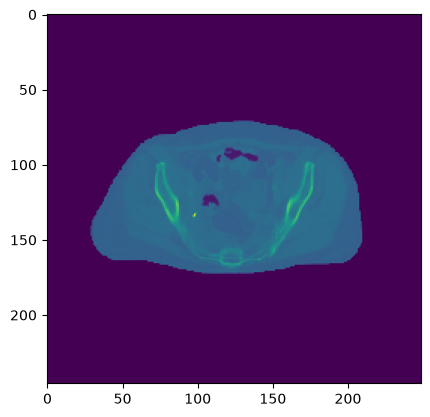

In [118]:
import matplotlib.pyplot as plt
plt.imshow(img_rot[0, 102].cpu())